In [63]:
import numpy as np
import pandas as pd

In [64]:
df = pd.read_csv(r'data//IMDB Dataset.csv').drop_duplicates()
df = df.iloc[:, :]
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [65]:
df.shape

(49582, 2)

In [66]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

## Basic Preprocessing
- Remove tags
- lowercase
- remove stopwords

In [67]:

import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


def basic_preprocessing(text):
    clean = re.compile('<.*?>')
    lowered_text = re.sub(clean, '', text).lower().strip()
    return ' '.join([word for word in lowered_text.split() if word not in stop_words])

In [68]:
df['review'] = df['review'].apply(basic_preprocessing)

In [69]:
df

,review,sentiment
0,one reviewers mentioned watching 1 oz episode ...,positive
1,wonderful little production. filming technique...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically there's family little boy (jake) thi...,negative
4,"petter mattei's ""love time money"" visually stu...",positive
...,...,...
49995,thought movie right good job. creative origina...,positive
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,catholic taught parochial elementary schools n...,negative
49998,going disagree previous comment side maltin on...,negative


In [70]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [71]:
X

,review
0,one reviewers mentioned watching 1 oz episode ...
1,wonderful little production. filming technique...
2,thought wonderful way spend time hot summer we...
3,basically there's family little boy (jake) thi...
4,"petter mattei's ""love time money"" visually stu..."
...,...
49995,thought movie right good job. creative origina...
49996,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,catholic taught parochial elementary schools n...
49998,going disagree previous comment side maltin on...


In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded

array([1, 1, 1, ..., 0, 0, 0])

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((39665, 1), (39665,), (9917, 1), (9917,))

## Vectorization

#### Bag of Words

In [79]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X_train_bow = cv.fit_transform(X_train['review'])
X_test_bow = cv.transform(X_test['review'])

In [80]:
X_train_bow.shape, X_test_bow.shape

((39665, 94644), (9917, 94644))

## Model Training

In [81]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()

mnb.fit(X_train_bow, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [82]:
y_pred  = mnb.predict(X_test_bow)

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      4939
           1       0.87      0.84      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



<Axes: >

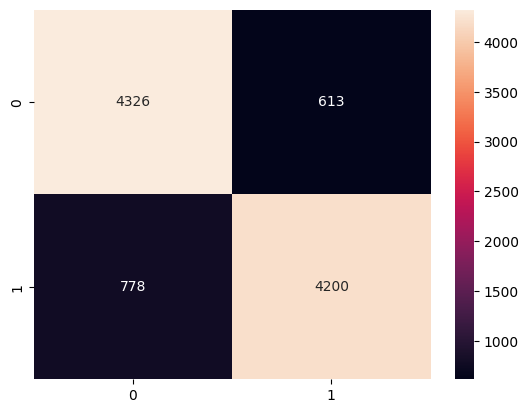

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d')

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4939
           1       0.85      0.85      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



<Axes: >

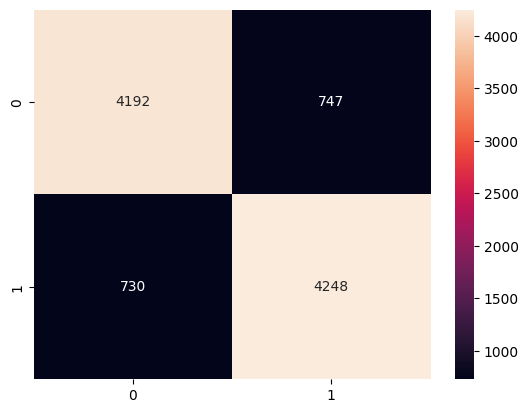

In [84]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf.fit(X_train_bow, y_train)
y_pred_rf = rf.predict(X_test_bow)
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d')

### Tf-Idf

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train['review'])
X_test_tfidf = tfidf.transform(X_test['review'])

In [102]:

from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()

rf.fit(X_train_tfidf,y_train)
y_pred = rf.predict(X_test_tfidf)

accuracy_score(y_test,y_pred)

0.8375516789351618